In [2]:
! pip install -q nltk spacy pandas matplotlib seaborn langdetect

import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"
])

print(" Dependencias instaladas correctamente")

 Dependencias instaladas correctamente


In [3]:
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag, pos_tag_sents
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

print(" Librerías importadas correctamente")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\steven16\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


 Librerías importadas correctamente


In [4]:
print("Cargando recursos de NLTK y spaCy...\n")

try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", quiet=True)

try:
    nltk.data.find("taggers/averaged_perceptron_tagger")
except LookupError:
    nltk.download("averaged_perceptron_tagger", quiet=True)

print(" Recursos de NLTK listos")

try:
    nlp = spacy.load("es_core_news_md")
    print(" Modelo de spaCy en español cargado correctamente")
except OSError:
    print(" Modelo no encontrado. Instalando...")
    import subprocess
    subprocess.run(
        ["python", "-m", "spacy", "download", "es_core_news_md"],
        check=True
    )
    nlp = spacy.load("es_core_news_md")
    print(" Modelo de spaCy instalado y cargado")

Cargando recursos de NLTK y spaCy...

 Recursos de NLTK listos
 Modelo de spaCy en español cargado correctamente


In [5]:
corpus = pd.read_csv("resenas_clean.csv")

corpus.head()

,texto,calificacion,polaridad,tipo_lugar,fuente,fecha,texto_limpio
0,"Un lugar espectacular y, sin duda, una visita ...",3,neutral,parque,google_maps,06/06/2026 02:10:30,un lugar espectacular y sin duda una visita ob...
1,"El parque es espectacular, las 3 son porque es...",3,neutral,parque,google_maps,06/05/2026 21:24:50,el parque es espectacular las son porque esta ...
2,"Increíble!! Lleno de flora y fauna del país, c...",5,positivo,parque,google_maps,06/05/2026 03:38:27,increíble lleno de flora y fauna del país con ...
3,Parque imperdível! O estacionamento fora do pa...,5,positivo,parque,google_maps,06/02/2026 17:46:50,parque imperdível o estacionamento fora do par...
4,Fabuloso lugar para apreciar y tener un contac...,5,positivo,parque,google_maps,06/02/2026 16:26:50,fabuloso lugar para apreciar y tener un contac...


In [6]:
# POS TAGGING CON NLTK 

resultados_nltk = []

for i, texto in enumerate(corpus["texto_limpio"]):

    tokens = word_tokenize(texto, preserve_line=True)
    pos_tags_nltk = pos_tag(tokens)

    resultados_nltk.append(pos_tags_nltk)

print("Cantidad de reseñas procesadas con NLTK:", len(resultados_nltk))
print("Cantidad total de reseñas en el corpus:", len(corpus))
# MOSTRAR ALGUNAS RESEÑAS PROCESADAS CON NLTK

for i, pos_tags in enumerate(resultados_nltk[:3]):

    print(f"\nRESEÑA {i+1}")
    print("POS TAGGING CON NLTK:")

    for word, tag in pos_tags:
        print(f"{word:15} → {tag}")

Cantidad de reseñas procesadas con NLTK: 1008
Cantidad total de reseñas en el corpus: 1008

RESEÑA 1
POS TAGGING CON NLTK:
un              → JJ
lugar           → NN
espectacular    → JJ
y               → NN
sin             → NN
duda            → NN
una             → JJ
visita          → NN
obligada        → NN
para            → NN
cualquiera      → NN
que             → NN
viaje           → VBZ
a               → DT
manuel          → NN
antonio         → NN
el              → NN
parque          → NN
está            → NN
muy             → NN
bien            → NN
mantenido       → NN
los             → NN
senderos        → JJ
principales     → NNS
son             → VBP
cómodos         → NN
de              → FW
recorrer        → FW
y               → FW
todo            → FW
se              → FW
encuentra       → FW
en              → FW
excelente       → FW
estado          → FW
nosotros        → FW
realizamos      → FW
únicamente      → FW
el              → FW
recorrido       → NN
principal    

In [7]:
# POS TAGGING CON SPACY 

resultados_spacy = []

for i, texto in enumerate(corpus["texto_limpio"]):

    doc = nlp(texto)

    pos_tags_spacy = []

    for token in doc:
        pos_tags_spacy.append((token.text, token.pos_, token.tag_, token.lemma_))

    resultados_spacy.append(pos_tags_spacy)

print("Cantidad de reseñas procesadas con spaCy:", len(resultados_spacy))
print("Cantidad total de reseñas en el corpus:", len(corpus))

# MOSTRAR ALGUNAS RESEÑAS PROCESADAS CON SPACY

for i, pos_tags in enumerate(resultados_spacy[:3]):

    print(f"\nRESEÑA {i+1}")
    print("POS TAGGING CON spaCy:")

    for word, pos, tag, lemma in pos_tags:
        print(f"{word:15} → POS: {pos:8} | TAG: {tag:8} | LEMA: {lemma}")

Cantidad de reseñas procesadas con spaCy: 1008
Cantidad total de reseñas en el corpus: 1008

RESEÑA 1
POS TAGGING CON spaCy:
un              → POS: DET      | TAG: DET      | LEMA: uno
lugar           → POS: NOUN     | TAG: NOUN     | LEMA: lugar
espectacular    → POS: ADJ      | TAG: ADJ      | LEMA: espectacular
y               → POS: CCONJ    | TAG: CCONJ    | LEMA: y
sin             → POS: ADP      | TAG: ADP      | LEMA: sin
duda            → POS: NOUN     | TAG: NOUN     | LEMA: duda
una             → POS: DET      | TAG: DET      | LEMA: uno
visita          → POS: NOUN     | TAG: NOUN     | LEMA: visita
obligada        → POS: ADJ      | TAG: ADJ      | LEMA: obligado
para            → POS: ADP      | TAG: ADP      | LEMA: para
cualquiera      → POS: PRON     | TAG: PRON     | LEMA: cualquiera
que             → POS: PRON     | TAG: PRON     | LEMA: que
viaje           → POS: VERB     | TAG: VERB     | LEMA: viajir
a               → POS: ADP      | TAG: ADP      | LEMA: a
manuel  

In [8]:
# COMPARACIÓN NLTK vs spaCy 

texto = corpus["texto_limpio"].iloc[0]

print("RESEÑA ORIGINAL:")
print(f'"{texto}"\n')

# NLTK
tokens_nltk = word_tokenize(texto, preserve_line=True)
pos_nltk = pos_tag(tokens_nltk)

# spaCy
doc_spacy = nlp(texto)

print("COMPARACIÓN NLTK vs spaCy:")
print(f"{'PALABRA':15} | {'NLTK':10} | {'spaCy POS':10} | {'spaCy LEMA'}")
print("-" * 60)

for i in range(min(len(tokens_nltk), len(doc_spacy))):
    palabra = tokens_nltk[i]
    etiqueta_nltk = pos_nltk[i][1]
    etiqueta_spacy = doc_spacy[i].pos_
    lema_spacy = doc_spacy[i].lemma_

    print(f"{palabra:15} | {etiqueta_nltk:10} | {etiqueta_spacy:10} | {lema_spacy}")

RESEÑA ORIGINAL:
"un lugar espectacular y sin duda una visita obligada para cualquiera que viaje a manuel antonio el parque está muy bien mantenido los senderos principales son cómodos de recorrer y todo se encuentra en excelente estado nosotros realizamos únicamente el recorrido principal ya que no tuvimos tiempo de explorar todos los senderos secundarios pero la experiencia fue muy buena de principio a fin las playas son sencillamente impresionantes de hecho creemos que una de ellas podría estar fácilmente entre las mejores playas de costa rica el agua es tranquila el entorno es hermoso y la combinación entre selva y playa crea un paisaje realmente único nuestro principal consejo es llegar lo más temprano posible si lográs adelantarte a los grupos organizados podés disfrutar varias horas con muy poca gente y vivir una experiencia mucho más tranquila nosotros estuvimos en temporada baja y durante la mañana la playa se disfrutaba muchísimo sin embargo hacia el mediodía comenzaron a lle

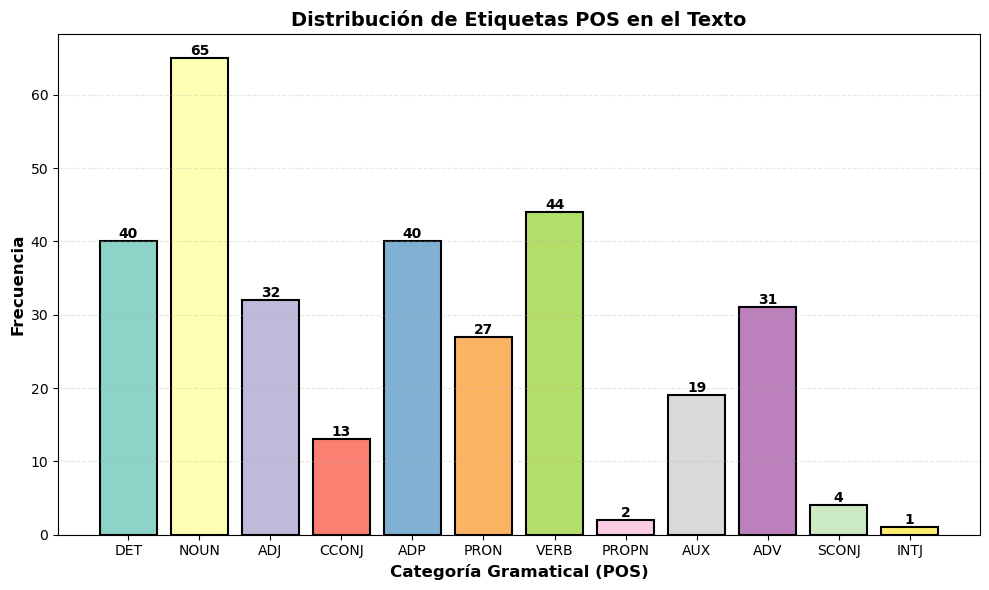

Total de palabras (sin puntuación): 318


In [12]:
# Cuenta cuántas veces aparece cada categoría gramatical
# y genera un gráfico de barras para visualizarlo
fig, ax = plt.subplots(figsize=(10, 6))

pos_counts = Counter([
    token.pos_ for token in doc
    if not token.is_punct and not token.is_space
])

pos_names = list(pos_counts.keys())
pos_values = list(pos_counts.values())

colors = plt.cm.Set3(range(len(pos_names)))
bars = ax.bar(pos_names, pos_values, color=colors, edgecolor="black", linewidth=1.5)

# Agrega el número encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f"{int(height)}",
            ha="center", va="bottom", fontweight="bold")

ax.set_xlabel("Categoría Gramatical (POS)", fontsize=12, fontweight="bold")
ax.set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
ax.set_title("Distribución de Etiquetas POS en el Texto", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print(f"Total de palabras (sin puntuación): {len(doc) - sum(1 for t in doc if t.is_punct or t.is_space)}")